# ADAUSDT future returns percentile analysis

??????? ????????? ??? ????????? ??????? parquet-????? ?? `targets/future_returns`, ??????? ?????????? ????????????? ??????? ??????????? ??? ?????????? `1m..120m` ? ?????? ???? ????? ?????? ??????????? ????????????? ?? ????? ????.

In [7]:
import io
import os
import re

import boto3
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import numpy as np
import pandas as pd
from dotenv import load_dotenv

BUCKET = "binance-data-downloader"
TARGETS_PREFIX = "targets"
TARGET_DATASET_NAME = "future_returns"
SYMBOL = "ADAUSDT"
INTERVAL = "1m"
PERCENTILES = [1, 5, 10, 25, 50, 75, 90, 95, 99]
HORIZONS = list(range(1, 121))
RETURN_COLUMNS = [f"return_{h}m" for h in HORIZONS]


def make_s3_client():
    load_dotenv()
    return boto3.client(
        "s3",
        endpoint_url=os.getenv("YC_ENDPOINT"),
        region_name=os.getenv("YC_REGION"),
        aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
    )

In [8]:
def list_future_return_keys(
    symbol: str = SYMBOL,
    bucket: str = BUCKET,
    targets_prefix: str = TARGETS_PREFIX,
    dataset_name: str = TARGET_DATASET_NAME,
    interval: str = INTERVAL,
    s3_client=None,
) -> list[str]:
    s3 = s3_client or make_s3_client()
    prefix = f"{targets_prefix.strip('/')}/{dataset_name}/symbol={symbol}/interval={interval}/"
    pattern = re.compile(r"/date=(\d{4}-\d{2}-\d{2})/data\.parquet$")
    keys = []
    for page in s3.get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            if pattern.search('/' + obj["Key"]):
                keys.append(obj["Key"])
    return sorted(keys)


def read_future_returns_dataset(
    symbol: str = SYMBOL,
    bucket: str = BUCKET,
    targets_prefix: str = TARGETS_PREFIX,
    dataset_name: str = TARGET_DATASET_NAME,
    interval: str = INTERVAL,
    s3_client=None,
) -> pd.DataFrame:
    s3 = s3_client or make_s3_client()
    keys = list_future_return_keys(symbol, bucket, targets_prefix, dataset_name, interval, s3)
    if not keys:
        raise FileNotFoundError("No future_returns parquet files found")

    frames = []
    expected_columns = ["open_time", *RETURN_COLUMNS]
    for key in keys:
        obj = s3.get_object(Bucket=bucket, Key=key)
        frame = pd.read_parquet(io.BytesIO(obj["Body"].read()), columns=expected_columns)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)

In [11]:
def build_percentile_statistics(
    returns_df: pd.DataFrame,
    percentiles: list[int] = PERCENTILES,
    horizons: list[int] = HORIZONS,
    exclude_zero_returns: bool = True,
) -> pd.DataFrame:
    rows = []
    for horizon in horizons:
        column = f"return_{horizon}m"
        values = pd.to_numeric(returns_df[column], errors="coerce").dropna()
        if exclude_zero_returns:
            values = values[values != 0]

        if values.empty:
            stats = {f"p{p}": np.nan for p in percentiles}
        else:
            quantiles = np.percentile(values.to_numpy(dtype="float64"), percentiles)
            stats = {f"p{p}": value for p, value in zip(percentiles, quantiles)}

        rows.append({"horizon": horizon, **stats})

    return pd.DataFrame(rows)


def plot_percentile_curves(percentile_df: pd.DataFrame, save_path: str | None = None):
    fig, ax = plt.subplots(figsize=(14, 8))
    percentile_labels = {
        1: "1-й перцентиль",
        5: "5-й перцентиль",
        10: "10-й перцентиль",
        25: "25-й перцентиль",
        50: "50-й перцентиль",
        75: "75-й перцентиль",
        90: "90-й перцентиль",
        95: "95-й перцентиль",
        99: "99-й перцентиль",
    }

    for percentile in PERCENTILES:
        column = f"p{percentile}"
        ax.plot(
            percentile_df["horizon"],
            percentile_df[column] * 100,
            label=percentile_labels[percentile],
        )

    ax.set_title("Перцентили будущих доходностей ADAUSDT по горизонту")
    ax.set_xlabel("Горизонт доходности, минут")
    ax.set_ylabel("Доходность, %")

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}%"))

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend(title="Перцентили")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax

In [4]:
# ???????? ????? target dataset ? ?????? percentile statistics.
s3 = make_s3_client()
future_returns_df = read_future_returns_dataset(s3_client=s3)
percentile_statistics = build_percentile_statistics(future_returns_df)

print("rows:", len(future_returns_df))
print("columns:", len(future_returns_df.columns))
display(percentile_statistics.head())
display(percentile_statistics.tail())

rows: 3157919
columns: 121


,horizon,p1,p5,p10,p25,p50,p75,p90,p95,p99
0,1,-0.004339,-0.002185,-0.001487,-0.000687,0.000046,0.000687,0.001484,0.002191,0.004407
1,2,-0.006043,-0.003021,-0.002039,-0.000922,0.000054,0.000923,0.002037,0.003034,0.006169
2,3,-0.007305,-0.003646,-0.002459,-0.001112,0.000054,0.001116,0.002462,0.003665,0.007491
3,4,-0.008387,-0.004171,-0.002815,-0.001265,0.000063,0.001268,0.002823,0.004196,0.008598
4,5,-0.009311,-0.004638,-0.003127,-0.001401,0.000050,0.001405,0.003135,0.004676,0.009576


,horizon,p1,p5,p10,p25,p50,p75,p90,p95,p99
115,116,-0.041853,-0.021132,-0.014107,-0.006216,0.000074,0.006295,0.014508,0.021944,0.045206
116,117,-0.042023,-0.021210,-0.014167,-0.006244,0.000074,0.006326,0.014581,0.022046,0.045407
117,118,-0.042175,-0.021313,-0.014228,-0.006269,0.000076,0.006354,0.014635,0.022137,0.045556
118,119,-0.042354,-0.021403,-0.014282,-0.006298,0.000074,0.006383,0.014702,0.022244,0.045786
119,120,-0.042547,-0.021492,-0.014344,-0.006323,0.000074,0.006410,0.014761,0.022341,0.045974


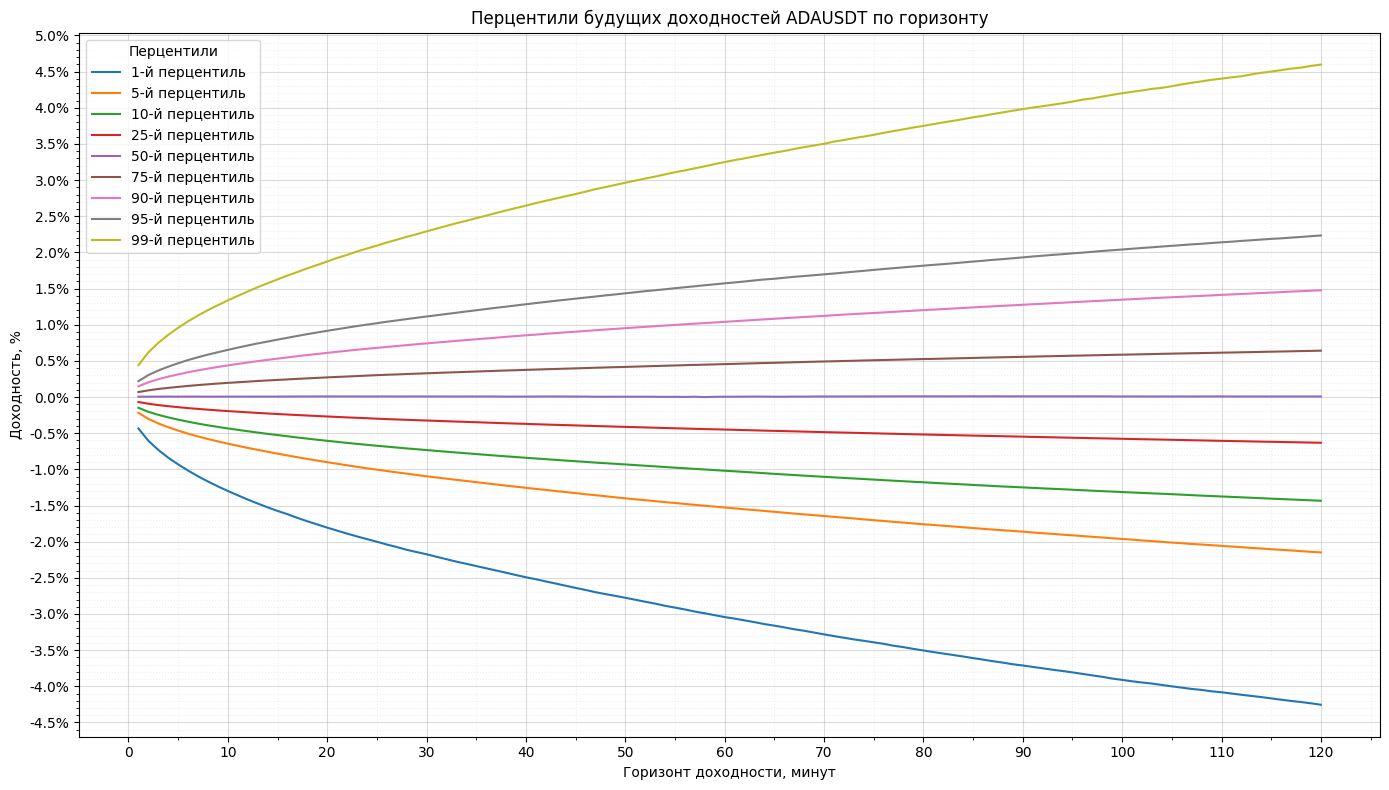

In [12]:
# ???? ????? ??????.
fig, ax = plot_percentile_curves(percentile_statistics)
plt.show()

In [6]:
# ???????????? ?????????? ???????????.
# percentile_statistics.to_parquet("adausdt_future_return_percentiles.parquet", index=False)
# percentile_statistics.to_csv("adausdt_future_return_percentiles.csv", index=False)
# fig, ax = plot_percentile_curves(percentile_statistics, save_path="adausdt_future_return_percentiles.png")

,horizon,median_abs_return,mean_abs_return,std_return
0,1,0.000687,0.001036,0.001673
1,2,0.000923,0.001416,0.002331
2,3,0.001114,0.001702,0.002818
3,4,0.001266,0.001945,0.003229
4,5,0.001403,0.002159,0.003582


,horizon,median_abs_return,mean_abs_return,std_return
115,116,0.006256,0.009702,0.015567
116,117,0.006284,0.009744,0.015633
117,118,0.006311,0.009784,0.015697
118,119,0.006340,0.009825,0.015761
119,120,0.006367,0.009865,0.015824


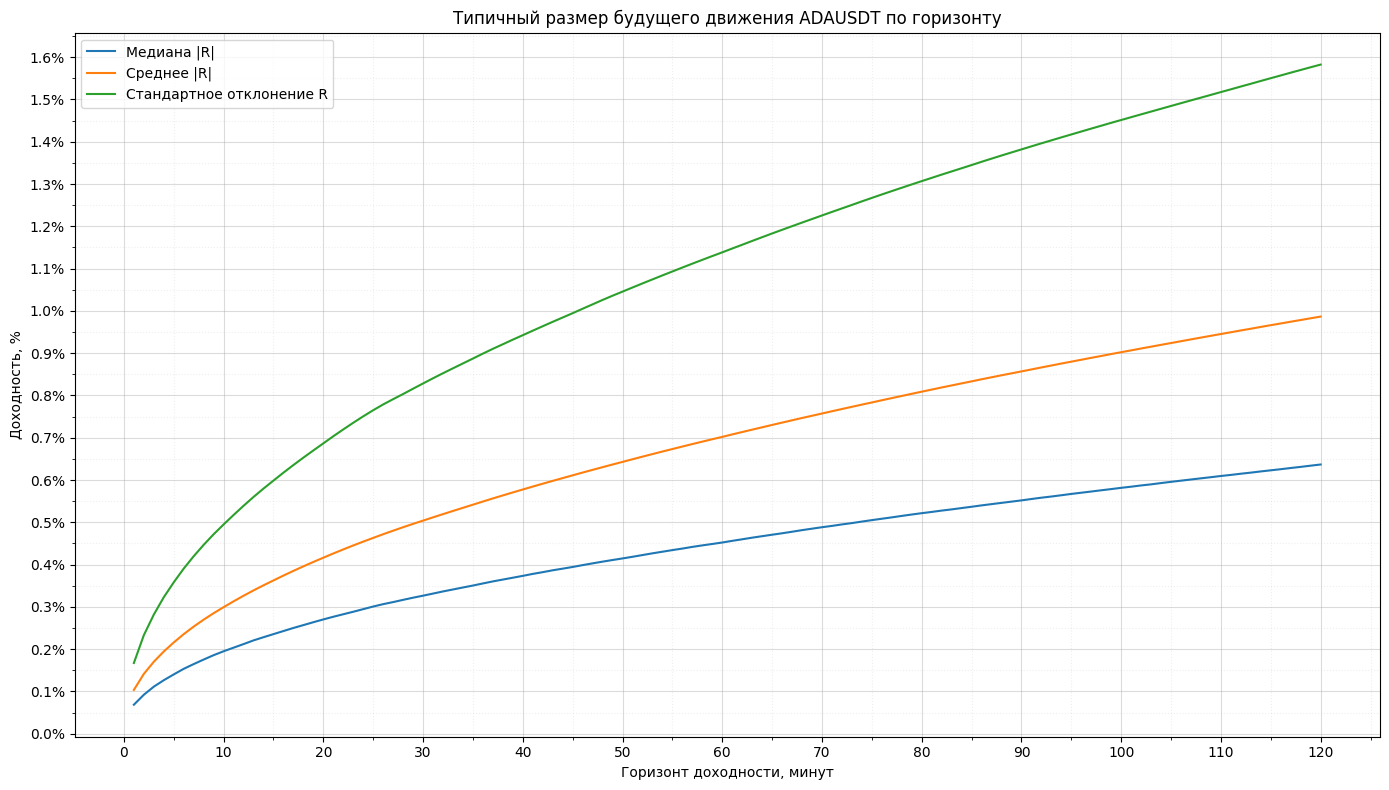

In [13]:
def build_typical_move_statistics(
    returns_df: pd.DataFrame,
    horizons: list[int] = HORIZONS,
    exclude_zero_returns: bool = True,
) -> pd.DataFrame:
    rows = []

    for horizon in horizons:
        column = f"return_{horizon}m"
        values = pd.to_numeric(returns_df[column], errors="coerce").dropna()

        if exclude_zero_returns:
            values = values[values != 0]

        if values.empty:
            rows.append(
                {
                    "horizon": horizon,
                    "median_abs_return": np.nan,
                    "mean_abs_return": np.nan,
                    "std_return": np.nan,
                }
            )
            continue

        rows.append(
            {
                "horizon": horizon,
                "median_abs_return": values.abs().median(),
                "mean_abs_return": values.abs().mean(),
                "std_return": values.std(),
            }
        )

    return pd.DataFrame(rows)


def plot_typical_move_statistics(
    typical_move_df: pd.DataFrame,
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 8))

    ax.plot(
        typical_move_df["horizon"],
        typical_move_df["median_abs_return"] * 100,
        label="Медиана |R|",
    )
    ax.plot(
        typical_move_df["horizon"],
        typical_move_df["mean_abs_return"] * 100,
        label="Среднее |R|",
    )
    ax.plot(
        typical_move_df["horizon"],
        typical_move_df["std_return"] * 100,
        label="Стандартное отклонение R",
    )

    ax.set_title("Типичный размер будущего движения ADAUSDT по горизонту")
    ax.set_xlabel("Горизонт доходности, минут")
    ax.set_ylabel("Доходность, %")

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}%"))

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax


typical_move_statistics = build_typical_move_statistics(future_returns_df)

display(typical_move_statistics.head())
display(typical_move_statistics.tail())

fig, ax = plot_typical_move_statistics(typical_move_statistics)
plt.show()

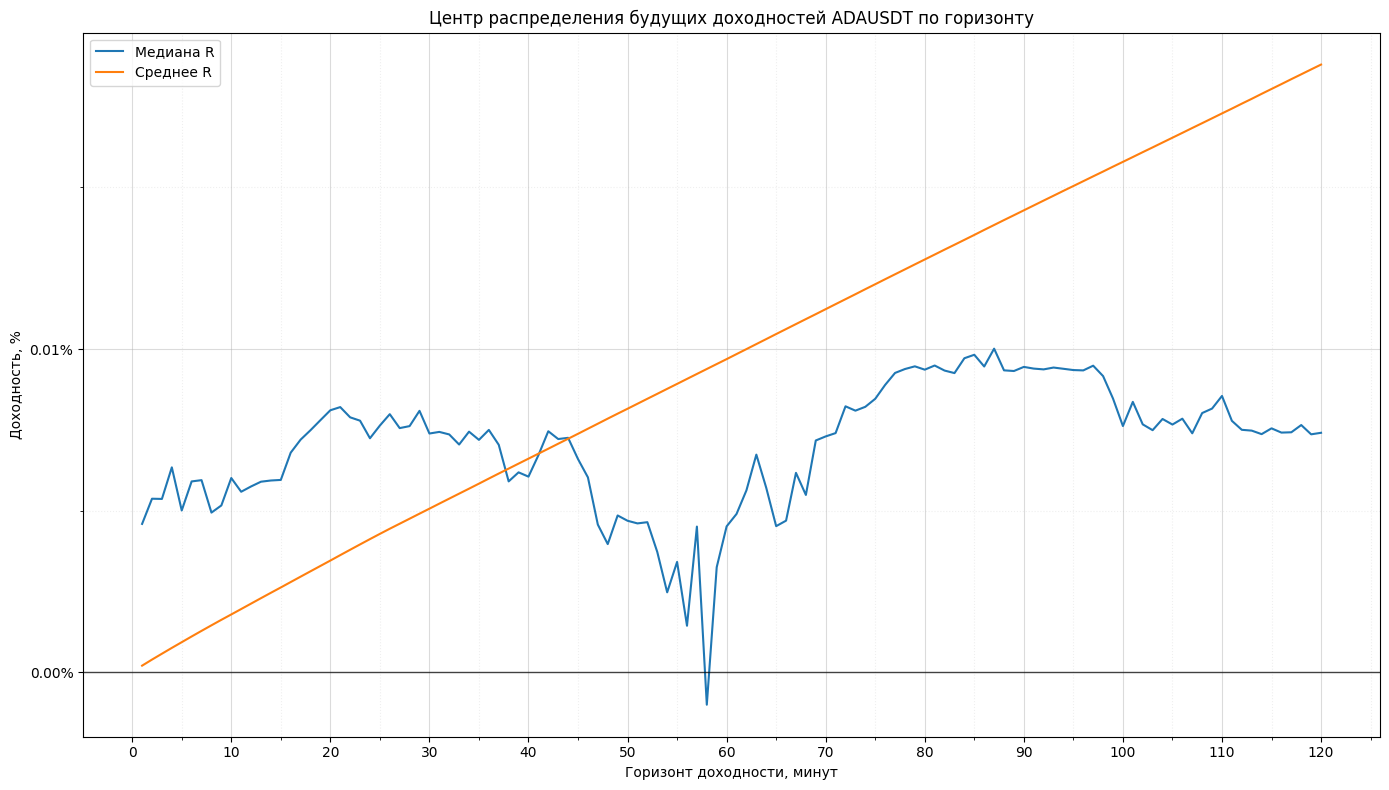

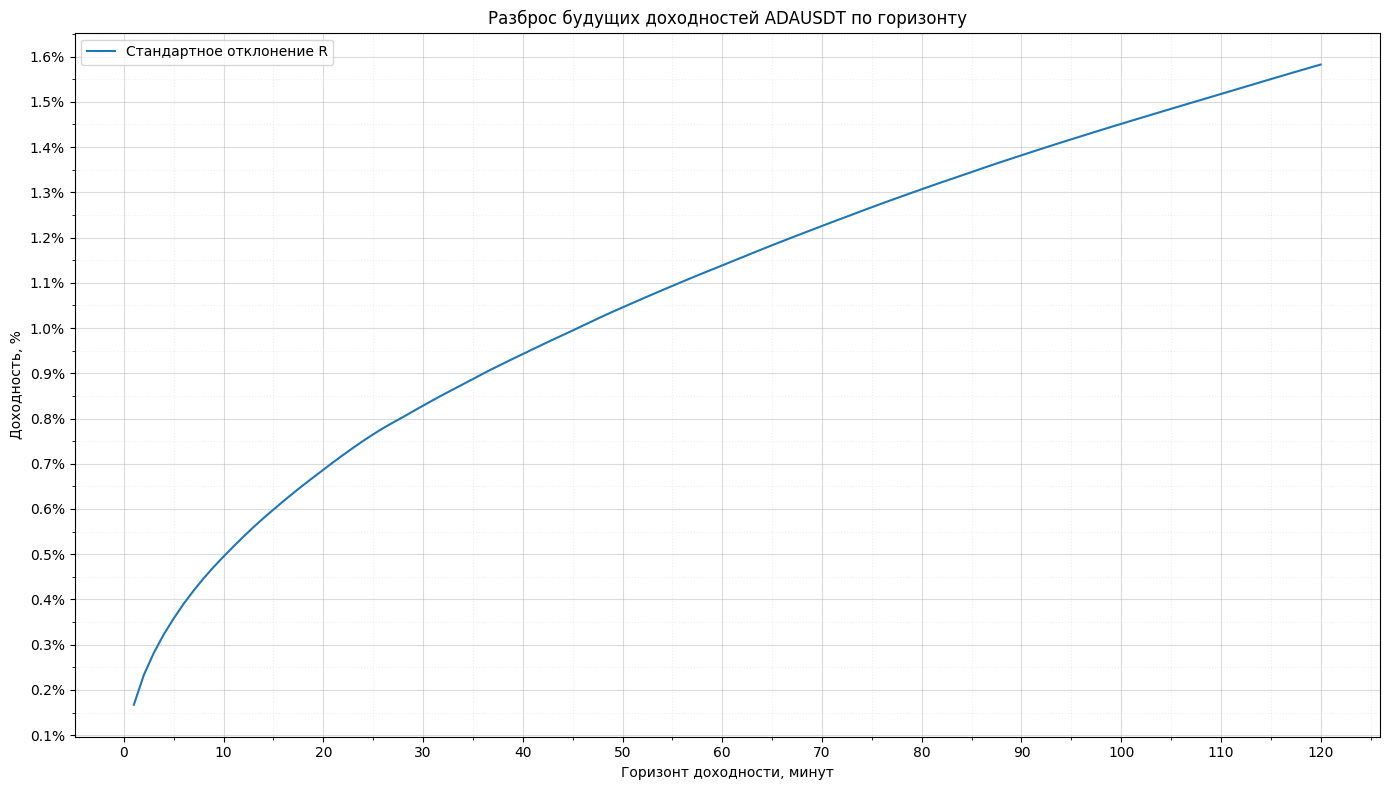

In [15]:
def plot_signed_return_center_statistics(
    signed_return_df: pd.DataFrame,
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 8))

    ax.plot(
        signed_return_df["horizon"],
        signed_return_df["median_return"] * 100,
        label="Медиана R",
    )
    ax.plot(
        signed_return_df["horizon"],
        signed_return_df["mean_return"] * 100,
        label="Среднее R",
    )

    ax.axhline(0, color="black", linewidth=1, alpha=0.7)

    ax.set_title("Центр распределения будущих доходностей ADAUSDT по горизонту")
    ax.set_xlabel("Горизонт доходности, минут")
    ax.set_ylabel("Доходность, %")

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.01))
    ax.yaxis.set_minor_locator(MultipleLocator(0.005))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax


def plot_signed_return_dispersion_statistics(
    signed_return_df: pd.DataFrame,
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 8))

    ax.plot(
        signed_return_df["horizon"],
        signed_return_df["std_return"] * 100,
        label="Стандартное отклонение R",
    )

    ax.set_title("Разброс будущих доходностей ADAUSDT по горизонту")
    ax.set_xlabel("Горизонт доходности, минут")
    ax.set_ylabel("Доходность, %")

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}%"))

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax


fig, ax = plot_signed_return_center_statistics(signed_return_statistics)
plt.show()

fig, ax = plot_signed_return_dispersion_statistics(signed_return_statistics)
plt.show()

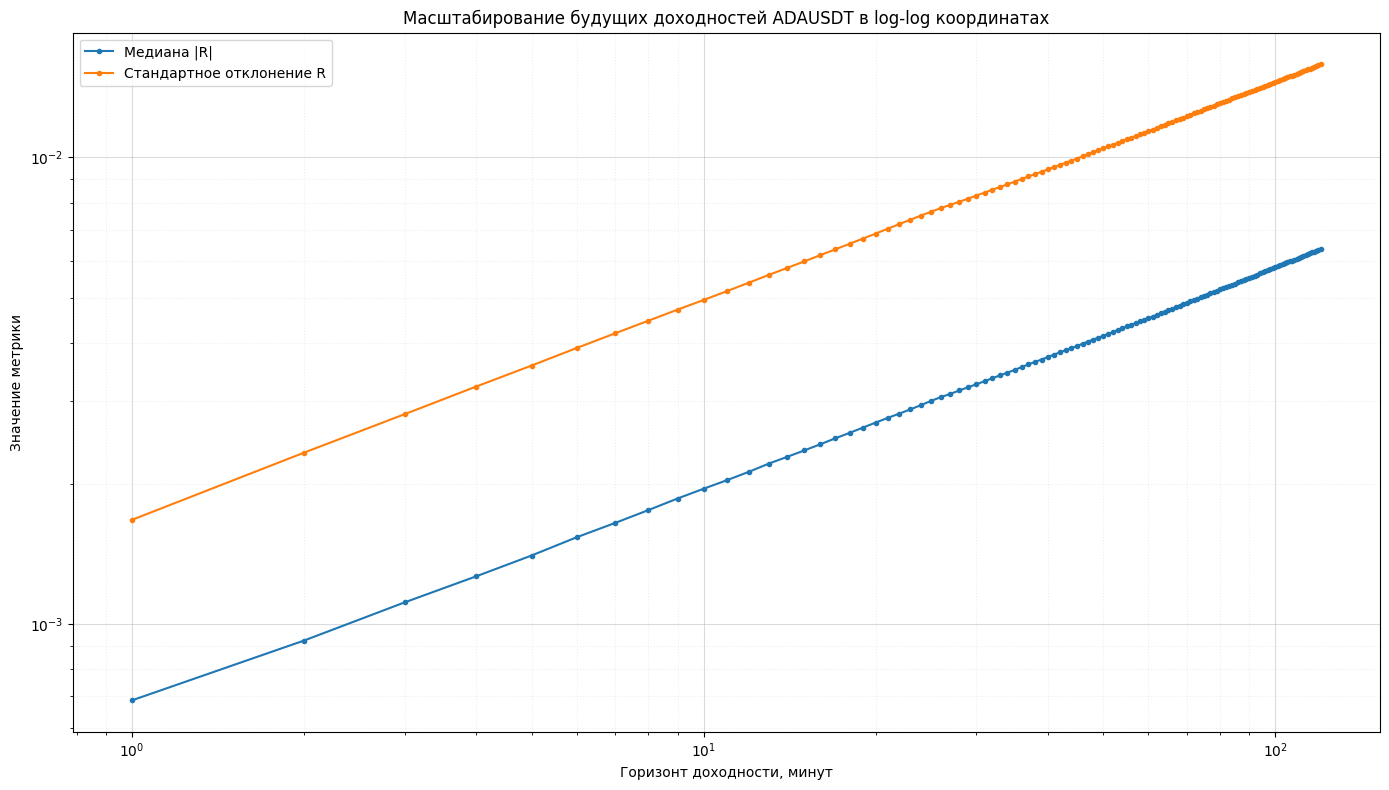

In [16]:
def plot_loglog_scaling_statistics(
    typical_move_df: pd.DataFrame,
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 8))

    valid_median = typical_move_df[
        (typical_move_df["horizon"] > 0)
        & (typical_move_df["median_abs_return"] > 0)
    ]

    valid_std = typical_move_df[
        (typical_move_df["horizon"] > 0)
        & (typical_move_df["std_return"] > 0)
    ]

    ax.plot(
        valid_median["horizon"],
        valid_median["median_abs_return"],
        marker="o",
        markersize=3,
        label="Медиана |R|",
    )

    ax.plot(
        valid_std["horizon"],
        valid_std["std_return"],
        marker="o",
        markersize=3,
        label="Стандартное отклонение R",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title("Масштабирование будущих доходностей ADAUSDT в log-log координатах")
    ax.set_xlabel("Горизонт доходности, минут")
    ax.set_ylabel("Значение метрики")

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax


fig, ax = plot_loglog_scaling_statistics(typical_move_statistics)
plt.show()

In [17]:
def estimate_loglog_slope(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    valid = (x > 0) & (y > 0)
    slope, intercept = np.polyfit(np.log(x[valid]), np.log(y[valid]), 1)
    return slope, intercept


median_slope, median_intercept = estimate_loglog_slope(
    typical_move_statistics["horizon"],
    typical_move_statistics["median_abs_return"],
)

std_slope, std_intercept = estimate_loglog_slope(
    typical_move_statistics["horizon"],
    typical_move_statistics["std_return"],
)

print(f"Наклон log-log для median(|R|): {median_slope:.4f}")
print(f"Наклон log-log для std(R): {std_slope:.4f}")

Наклон log-log для median(|R|): 0.4719
Наклон log-log для std(R): 0.4668


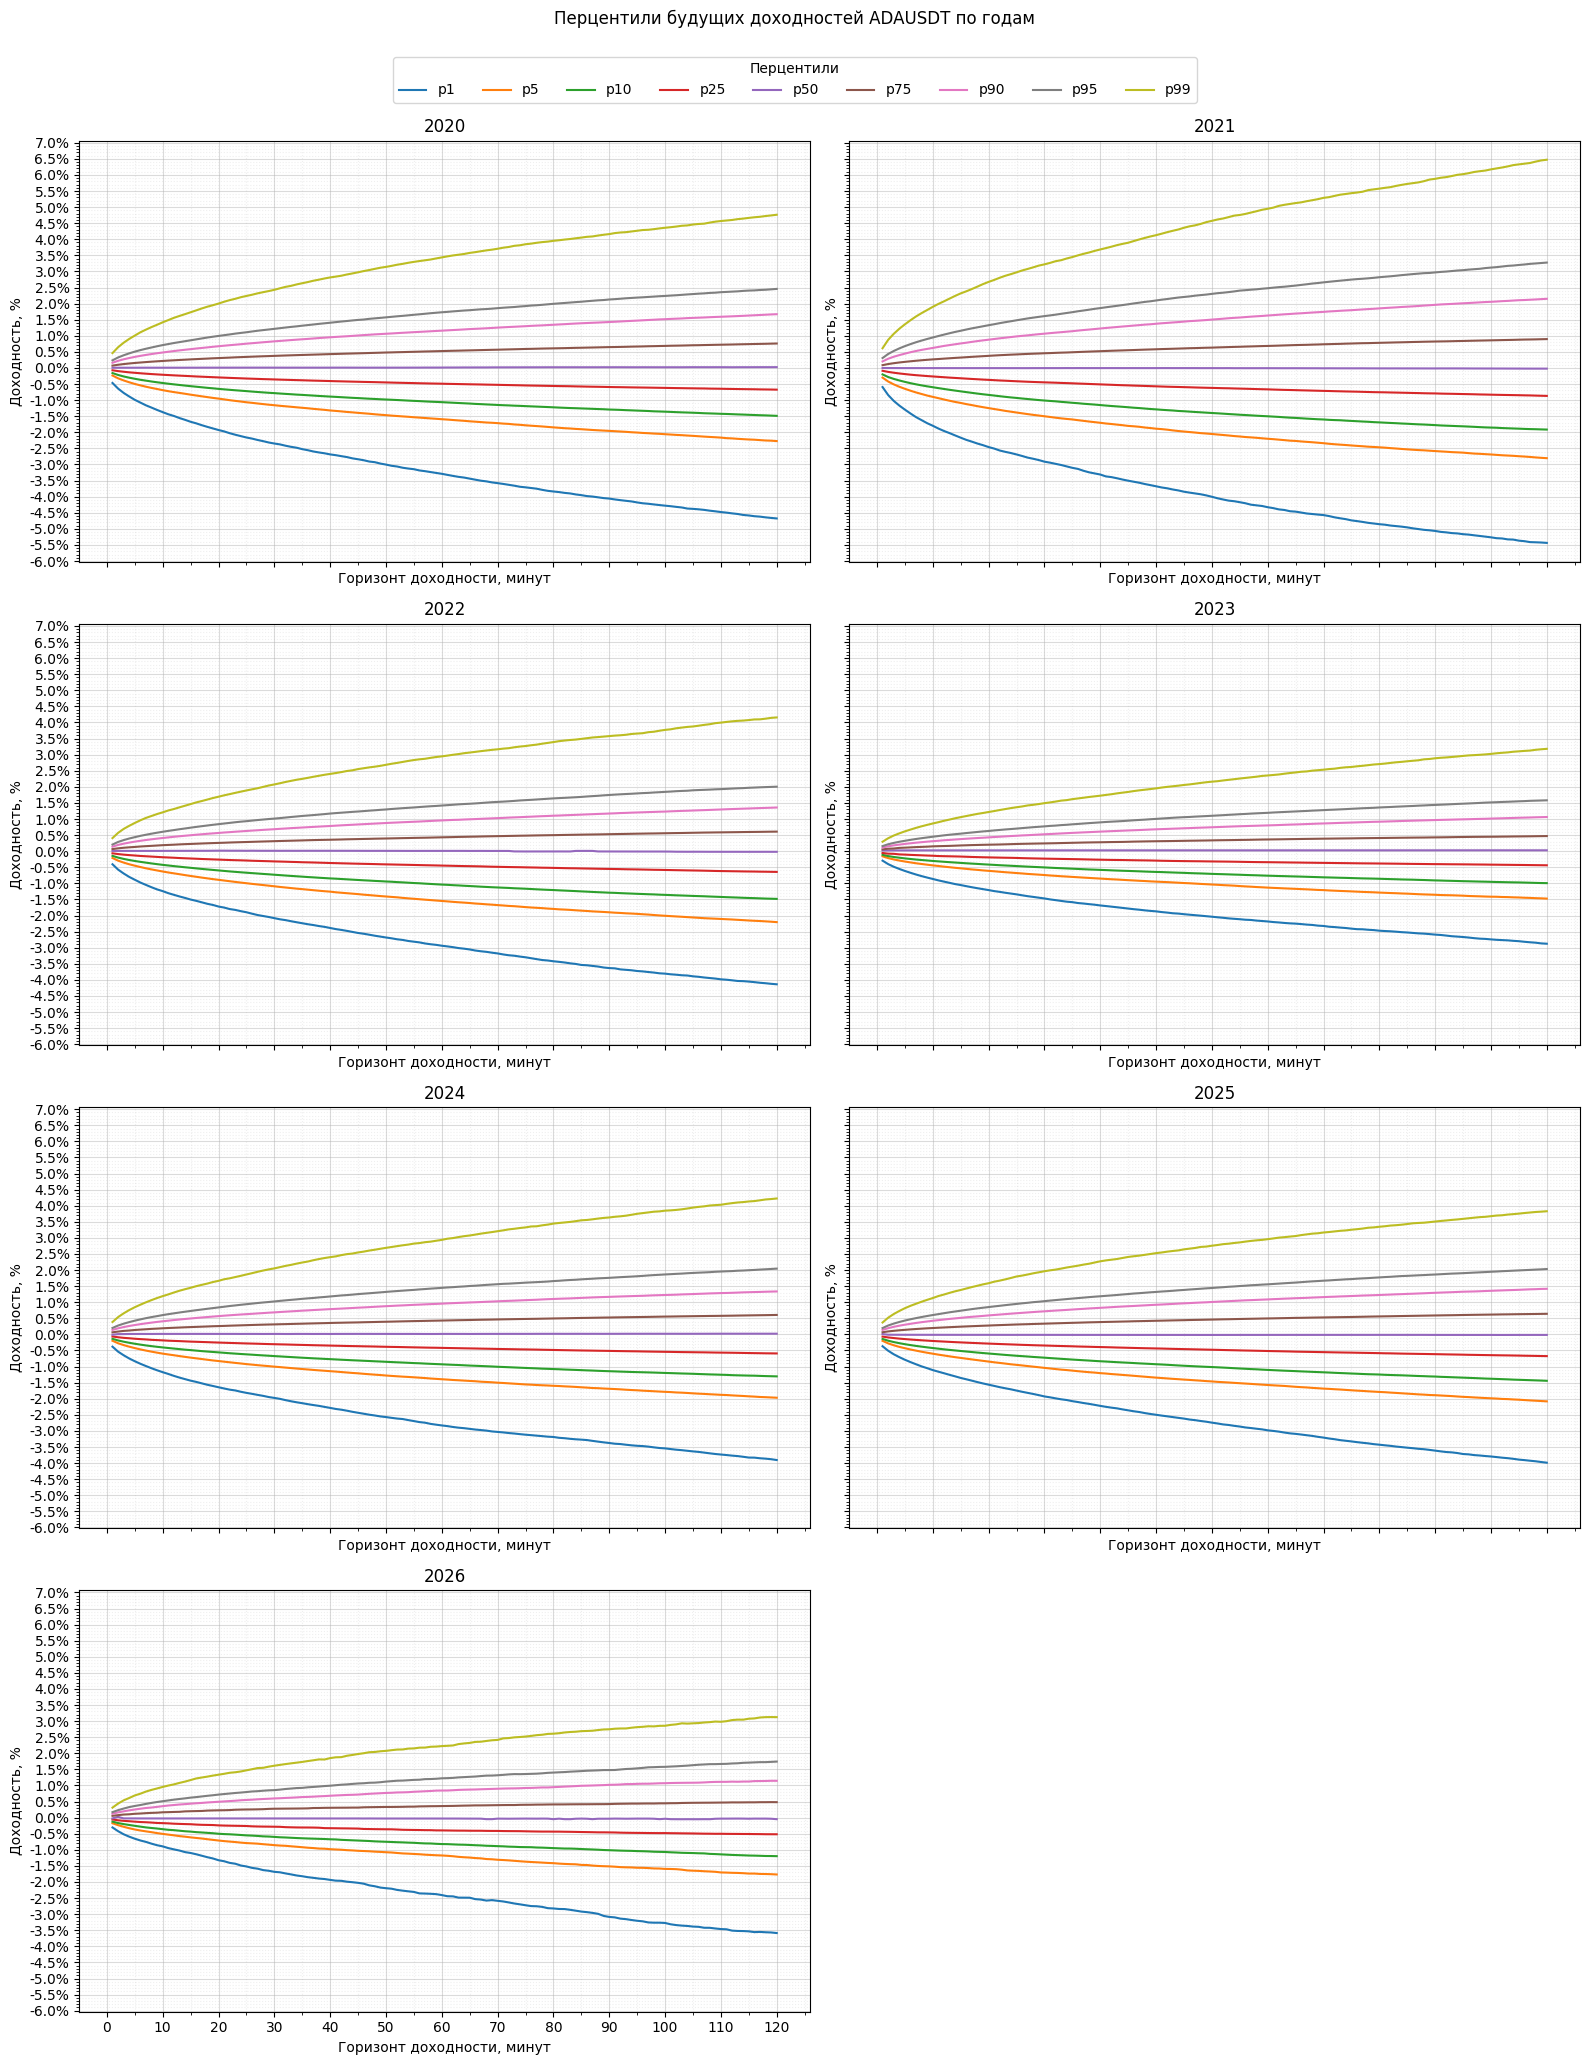

In [18]:
def build_percentile_statistics_by_year(
    returns_df: pd.DataFrame,
    percentiles: list[int] = PERCENTILES,
    horizons: list[int] = HORIZONS,
    exclude_zero_returns: bool = True,
) -> dict[int, pd.DataFrame]:
    df = returns_df.copy()
    df["year"] = pd.to_datetime(df["open_time"], unit="ms", utc=True).dt.year

    result = {}

    for year, year_df in df.groupby("year"):
        result[year] = build_percentile_statistics(
            year_df,
            percentiles=percentiles,
            horizons=horizons,
            exclude_zero_returns=exclude_zero_returns,
        )

    return result


def plot_percentile_curves_by_year(
    percentile_stats_by_year: dict[int, pd.DataFrame],
    save_path: str | None = None,
):
    years = sorted(percentile_stats_by_year.keys())
    n_years = len(years)

    n_cols = 2
    n_rows = int(np.ceil(n_years / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.array(axes).reshape(-1)

    percentile_labels = {
        1: "p1",
        5: "p5",
        10: "p10",
        25: "p25",
        50: "p50",
        75: "p75",
        90: "p90",
        95: "p95",
        99: "p99",
    }

    for ax, year in zip(axes, years):
        stats_df = percentile_stats_by_year[year]

        for percentile in PERCENTILES:
            column = f"p{percentile}"
            ax.plot(
                stats_df["horizon"],
                stats_df[column] * 100,
                label=percentile_labels[percentile],
            )

        ax.set_title(str(year))
        ax.set_xlabel("Горизонт доходности, минут")
        ax.set_ylabel("Доходность, %")

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        ax.yaxis.set_major_locator(MultipleLocator(0.5))
        ax.yaxis.set_minor_locator(MultipleLocator(0.1))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}%"))

        ax.grid(True, which="major", alpha=0.45)
        ax.grid(True, which="minor", alpha=0.2, linestyle=":")

    for ax in axes[n_years:]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Перцентили",
        loc="upper center",
        ncol=len(PERCENTILES),
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle("Перцентили будущих доходностей ADAUSDT по годам", y=1.03)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, axes


percentile_statistics_by_year = build_percentile_statistics_by_year(future_returns_df)

fig, axes = plot_percentile_curves_by_year(percentile_statistics_by_year)
plt.show()

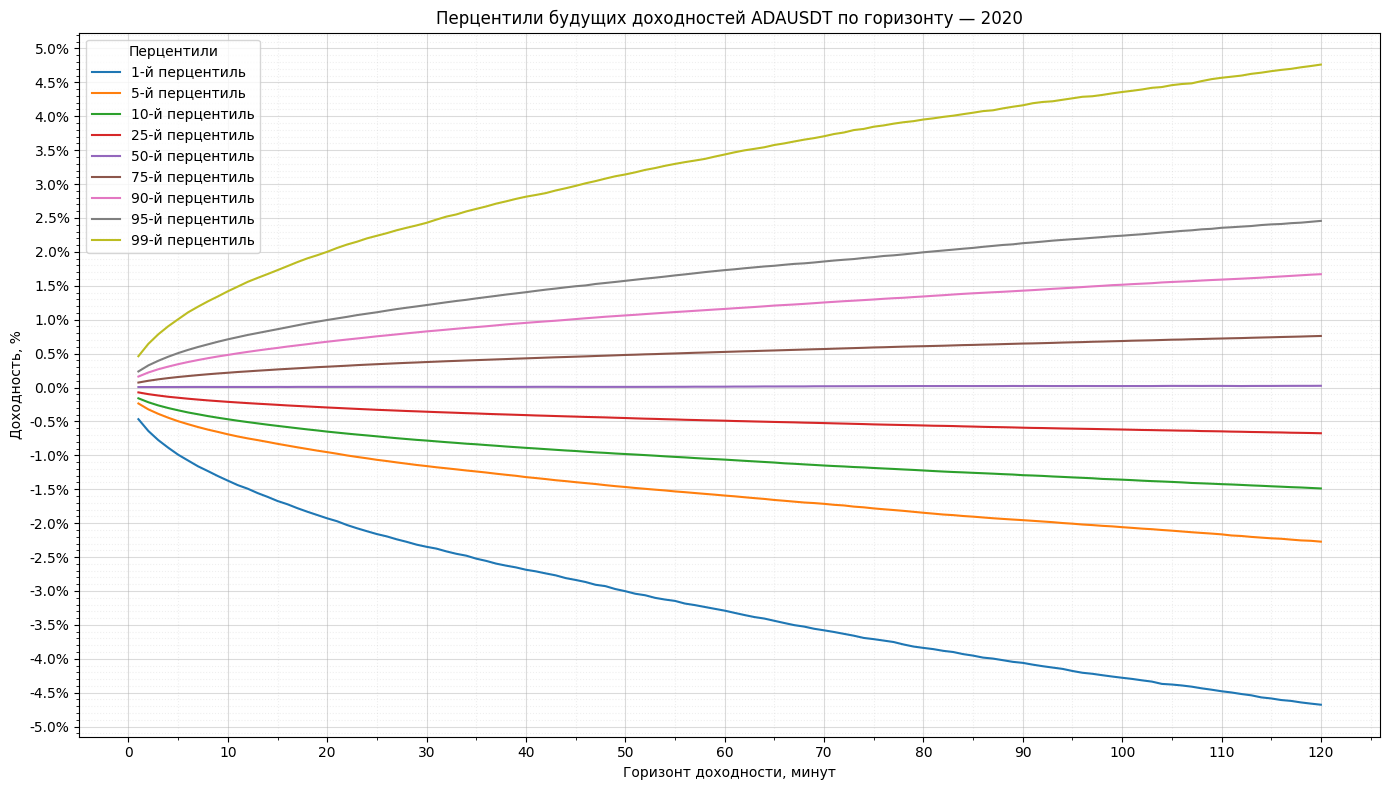

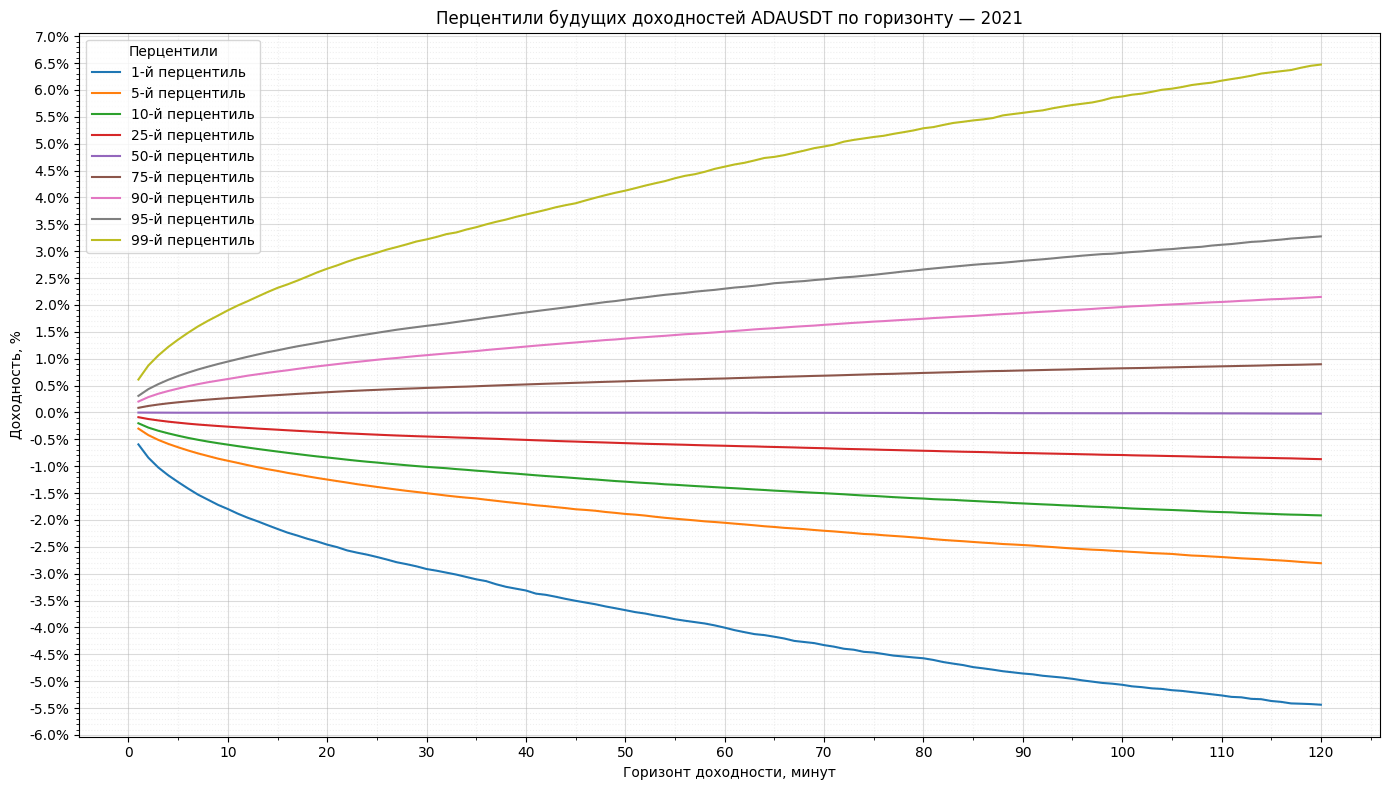

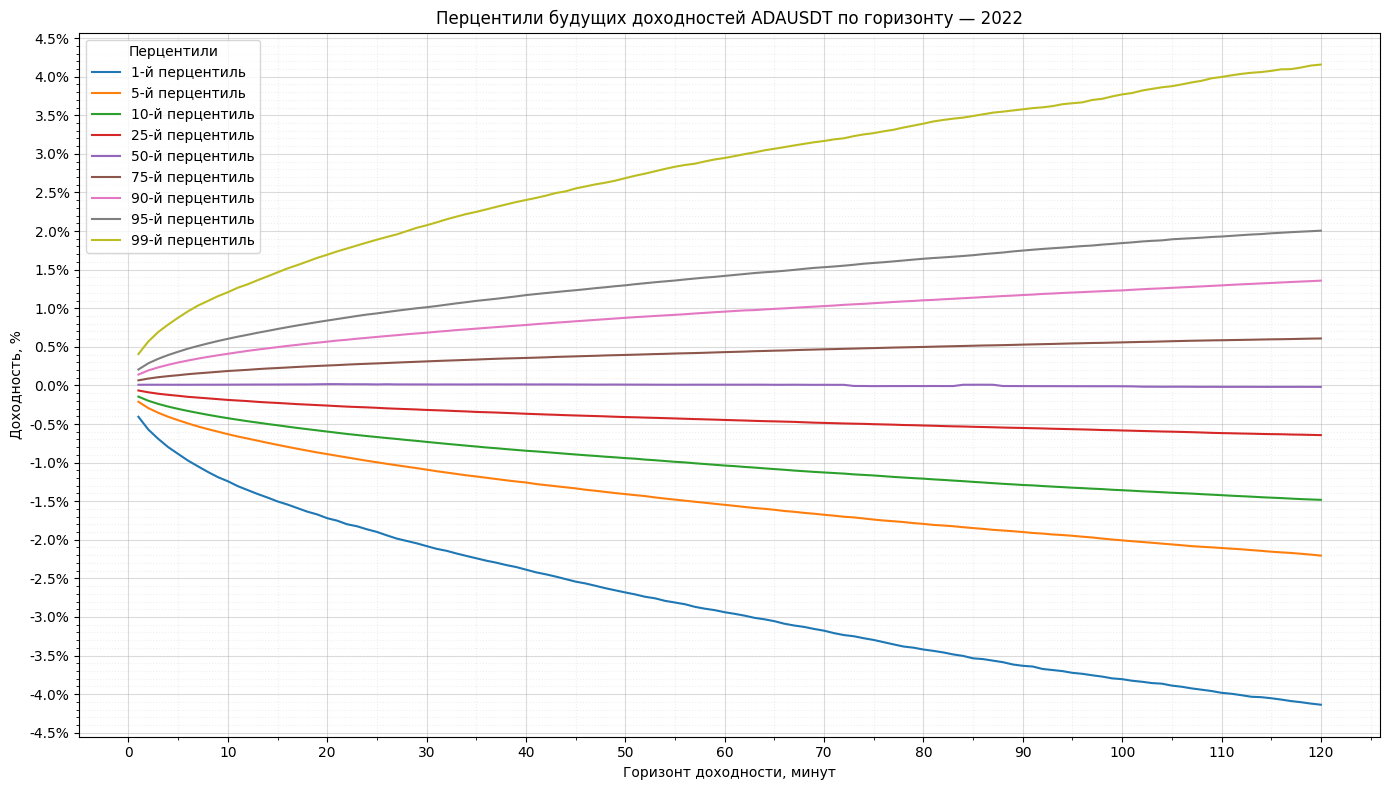

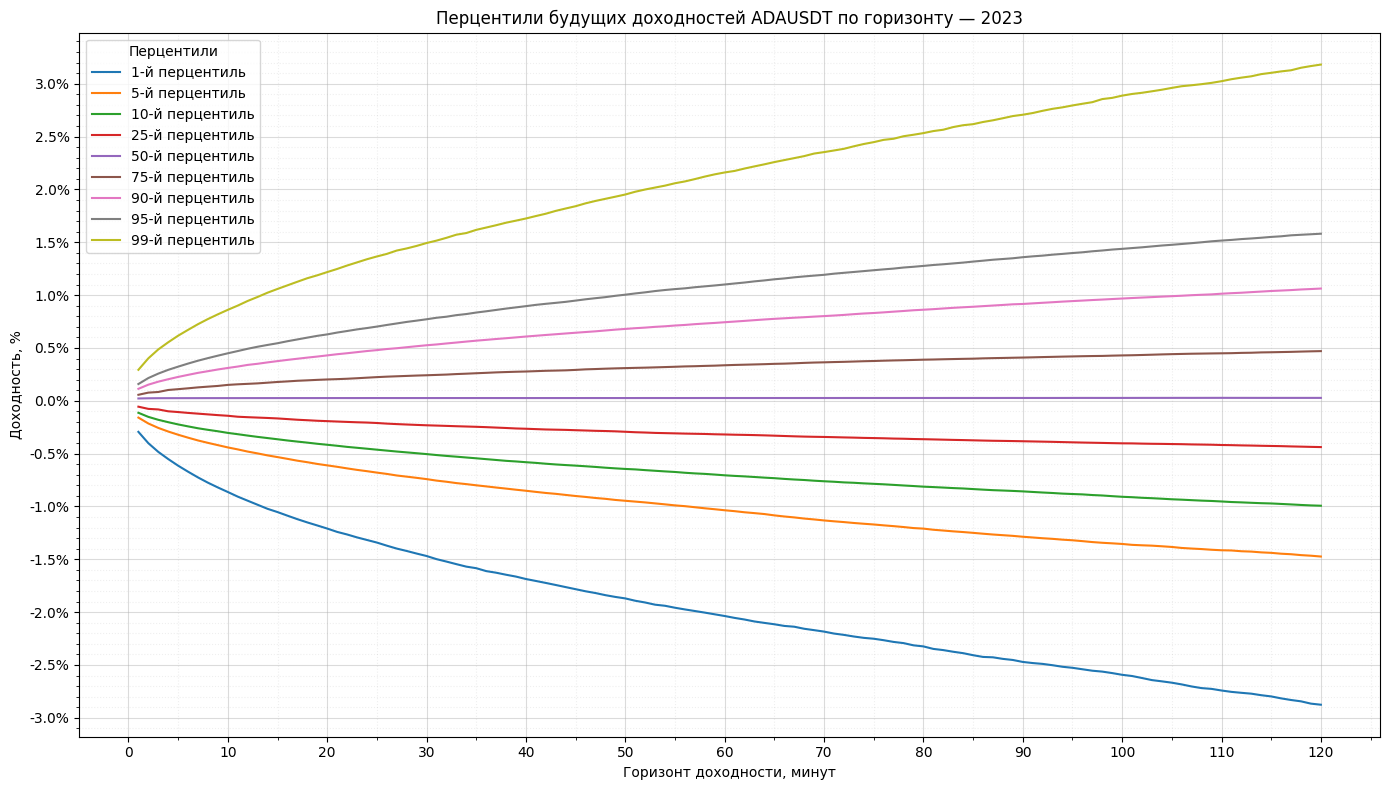

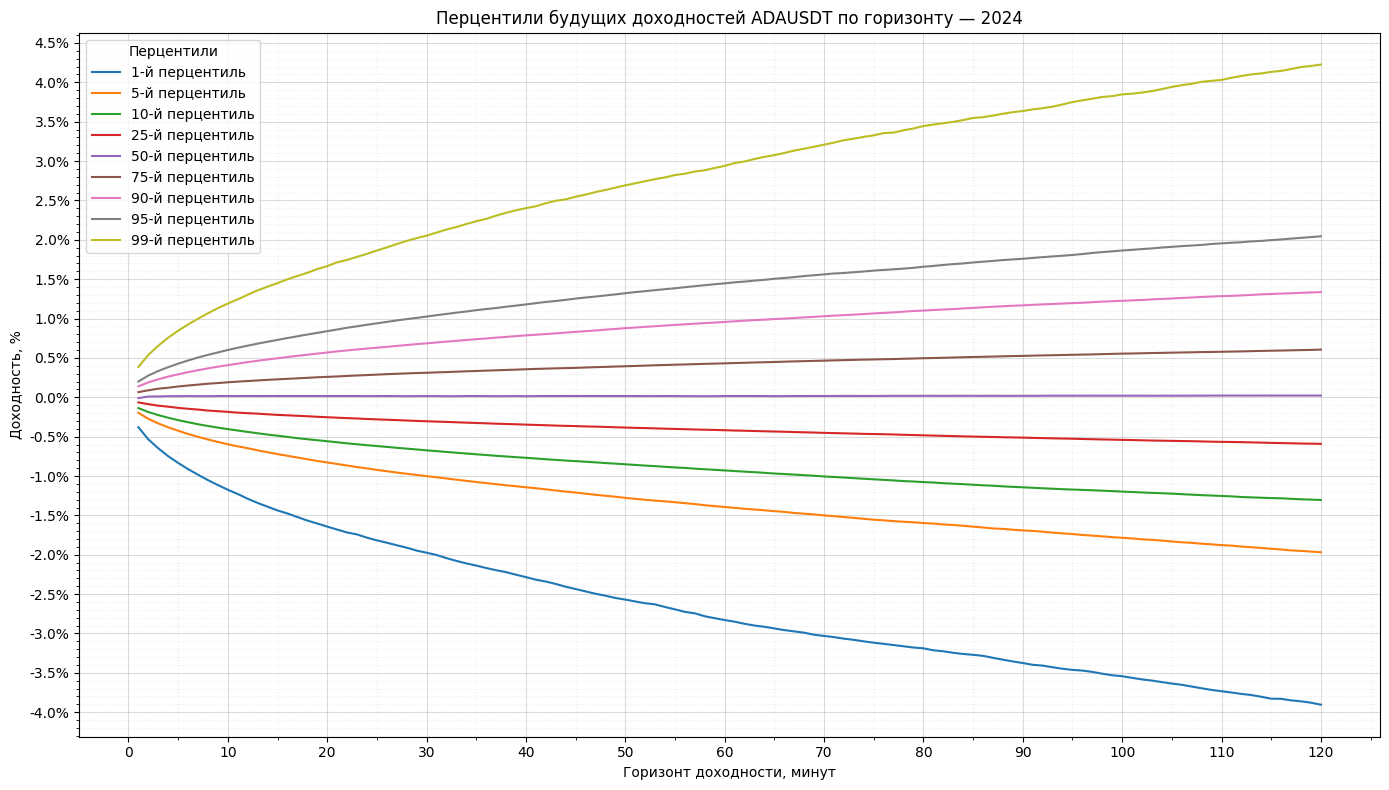

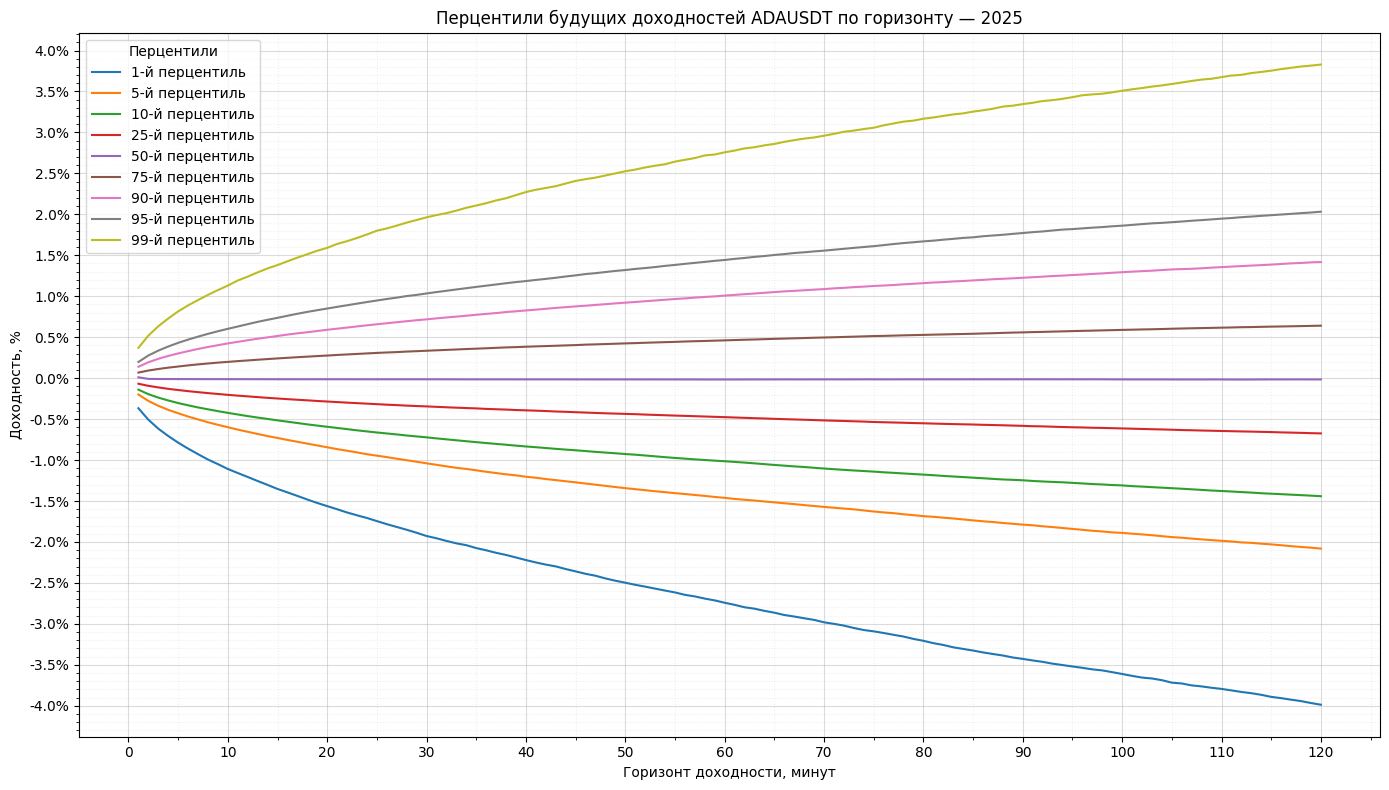

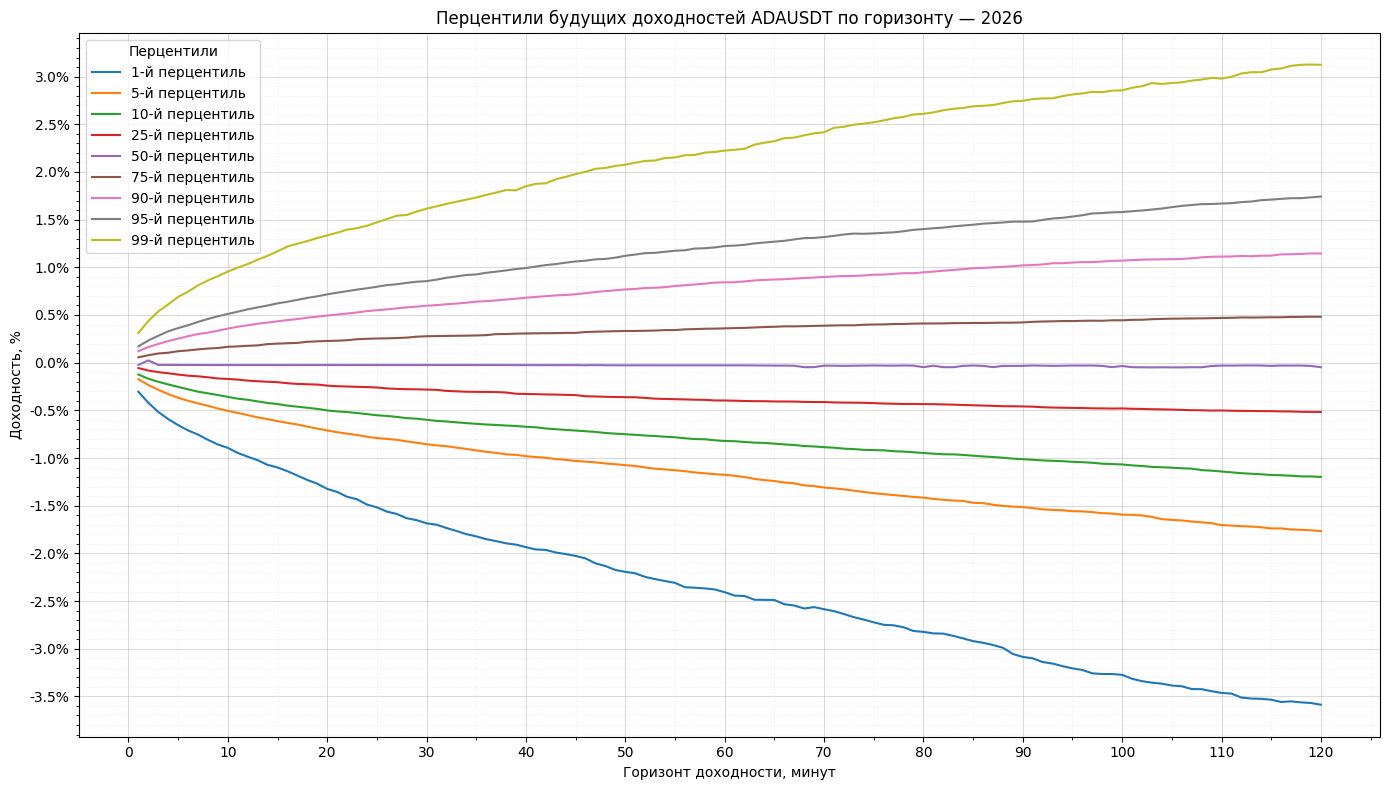

In [19]:
for year, stats_df in percentile_statistics_by_year.items():
    fig, ax = plot_percentile_curves(stats_df)
    ax.set_title(f"Перцентили будущих доходностей ADAUSDT по горизонту — {year}")
    plt.show()